# Coca-Cola vs PepsiCo: A Financial Comparison

## 1. Introduction

This project compares the financial performance of Coca-Cola and PepsiCo from 2020 to 2025.  
The main objective is to evaluate which company shows stronger performance in terms of profitability and financial stability.  
The target users are business students and beginner investors who want to understand how financial ratios can be used to compare company performance.

## 2. Data Source

The dataset used in this project was retrieved from WRDS through the `comp.funda` table.  
The analysis focuses on two companies: Coca-Cola (`KO`) and PepsiCo (`PEP`).  
The sample period covers fiscal years 2020 to 2025.

The main variables used are:
- `fyear`: fiscal year
- `sale`: revenue
- `ni`: net income
- `at`: total assets
- `lt`: total liabilities
- `act`: current assets
- `lct`: current liabilities

These variables are used to calculate net profit margin, current ratio, and debt ratio.

## 3. Connect to WRDS

In this section, Python is connected to the WRDS platform using the `wrds` library.  
This connection allows the notebook to directly access financial data stored in WRDS databases.

A valid WRDS account is required to run this notebook.  
After the connection is established, the notebook can retrieve company-level accounting data for further analysis.

In [4]:
import wrds
import pandas as pd

db = wrds.Connection()

Enter your WRDS username [HUAWEI]: fzh123
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\HUAWEI\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


## 4. Retrieve Data Using SQL

The financial data used in this project is retrieved from the `comp.funda` table in WRDS.  
SQL queries are used to select the required variables and filter the observations by company ticker and fiscal year.

Two companies are examined in this project:
- Coca-Cola (`KO`)
- PepsiCo (`PEP`)

The selected variables include revenue, net income, total assets, total liabilities, current assets, and current liabilities.  
These variables provide the foundation for ratio calculation and financial comparison.

In [5]:
db.list_tables(library='comp')[:20]

['aco_amda',
 'aco_imda',
 'aco_indfnta',
 'aco_indfntq',
 'aco_indfntytd',
 'aco_indsta',
 'aco_indstq',
 'aco_indstytd',
 'aco_notesa',
 'aco_notesq',
 'aco_notessa',
 'aco_notesytd',
 'aco_pnfnda',
 'aco_pnfndq',
 'aco_pnfndytd',
 'aco_pnfnta',
 'aco_pnfntq',
 'aco_pnfntytd',
 'aco_transa',
 'aco_transq']

In [6]:
sql_query = """
SELECT fyear, sale, ni, at, lt, act, lct
FROM comp.funda
WHERE tic = 'KO'
AND fyear >= 2020
ORDER BY fyear
"""

ko_data = db.raw_sql(sql_query)
ko_data

,fyear,sale,ni,at,lt,act,lct
0,2020,33014.0,7747.0,87296.0,66012.0,19240.0,14601.0
1,2020,33014.0,7747.0,87296.0,<NA>,<NA>,<NA>
2,2021,38655.0,9771.0,94354.0,69494.0,22545.0,19950.0
3,2021,38655.0,9771.0,94354.0,<NA>,<NA>,<NA>
4,2022,43004.0,9542.0,92763.0,66937.0,22591.0,19724.0
5,2022,43004.0,9542.0,92763.0,<NA>,<NA>,<NA>
6,2023,45754.0,10714.0,97703.0,70223.0,26732.0,23571.0
7,2023,45754.0,10714.0,97703.0,<NA>,<NA>,<NA>
8,2024,47061.0,10631.0,100549.0,74177.0,25997.0,25249.0
9,2024,47061.0,10631.0,100549.0,<NA>,<NA>,<NA>


In [7]:
sql_query = """
SELECT fyear, sale, ni, at, lt, act, lct
FROM comp.funda
WHERE tic = 'PEP'
AND fyear >= 2020
ORDER BY fyear
"""

pep_data = db.raw_sql(sql_query)
pep_data

,fyear,sale,ni,at,lt,act,lct
0,2020,70372.0,7120.0,92918.0,79366.0,23001.0,23372.0
1,2020,70372.0,7120.0,92918.0,<NA>,<NA>,<NA>
2,2021,79474.0,7618.0,92377.0,76226.0,21783.0,26220.0
3,2021,79474.0,7618.0,92377.0,<NA>,<NA>,<NA>
4,2022,86392.0,8910.0,92187.0,74914.0,21539.0,26785.0
5,2022,86392.0,8910.0,92187.0,<NA>,<NA>,<NA>
6,2023,91471.0,9074.0,100495.0,81858.0,26950.0,31647.0
7,2023,91471.0,9074.0,100495.0,<NA>,<NA>,<NA>
8,2024,91854.0,9578.0,99467.0,81296.0,25826.0,31536.0
9,2024,91854.0,9578.0,99467.0,<NA>,<NA>,<NA>


## 5. Data Cleaning and Ratio Calculation

After retrieving the raw data from WRDS, the two company datasets are combined into a single DataFrame.  
The data is then cleaned to remove duplicate or incomplete rows so that each company has only one observation for each fiscal year.

Three financial ratios are calculated for further analysis:

- **Net Profit Margin** = Net Income / Revenue  
- **Current Ratio** = Current Assets / Current Liabilities  
- **Debt Ratio** = Total Liabilities / Total Assets  

These ratios help evaluate profitability, liquidity, and financial stability.

In [8]:
ko_data["company"] = "Coca-Cola"
pep_data["company"] = "PepsiCo"

financial_data = pd.concat([ko_data, pep_data], ignore_index=True)
financial_data

,fyear,sale,ni,at,lt,act,lct,company
0,2020,33014.0,7747.0,87296.0,66012.0,19240.0,14601.0,Coca-Cola
1,2020,33014.0,7747.0,87296.0,<NA>,<NA>,<NA>,Coca-Cola
2,2021,38655.0,9771.0,94354.0,69494.0,22545.0,19950.0,Coca-Cola
3,2021,38655.0,9771.0,94354.0,<NA>,<NA>,<NA>,Coca-Cola
4,2022,43004.0,9542.0,92763.0,66937.0,22591.0,19724.0,Coca-Cola
5,2022,43004.0,9542.0,92763.0,<NA>,<NA>,<NA>,Coca-Cola
6,2023,45754.0,10714.0,97703.0,70223.0,26732.0,23571.0,Coca-Cola
7,2023,45754.0,10714.0,97703.0,<NA>,<NA>,<NA>,Coca-Cola
8,2024,47061.0,10631.0,100549.0,74177.0,25997.0,25249.0,Coca-Cola
9,2024,47061.0,10631.0,100549.0,<NA>,<NA>,<NA>,Coca-Cola


In [9]:
financial_data.dtypes

fyear        Int64
sale       Float64
ni         Float64
at         Float64
lt         Float64
act        Float64
lct        Float64
company     object
dtype: object

In [10]:
financial_data.isna().sum()

fyear       0
sale        0
ni          0
at          0
lt         12
act        12
lct        12
company     0
dtype: int64

In [11]:
financial_data["net_profit_margin"] = financial_data["ni"] / financial_data["sale"]
financial_data["current_ratio"] = financial_data["act"] / financial_data["lct"]
financial_data["debt_ratio"] = financial_data["lt"] / financial_data["at"]

financial_data

,fyear,sale,ni,at,lt,act,lct,company,net_profit_margin,current_ratio,debt_ratio
0,2020,33014.0,7747.0,87296.0,66012.0,19240.0,14601.0,Coca-Cola,0.234658,1.317718,0.756186
1,2020,33014.0,7747.0,87296.0,<NA>,<NA>,<NA>,Coca-Cola,0.234658,<NA>,<NA>
2,2021,38655.0,9771.0,94354.0,69494.0,22545.0,19950.0,Coca-Cola,0.252775,1.130075,0.736524
3,2021,38655.0,9771.0,94354.0,<NA>,<NA>,<NA>,Coca-Cola,0.252775,<NA>,<NA>
4,2022,43004.0,9542.0,92763.0,66937.0,22591.0,19724.0,Coca-Cola,0.221886,1.145356,0.721592
5,2022,43004.0,9542.0,92763.0,<NA>,<NA>,<NA>,Coca-Cola,0.221886,<NA>,<NA>
6,2023,45754.0,10714.0,97703.0,70223.0,26732.0,23571.0,Coca-Cola,0.234165,1.134105,0.718739
7,2023,45754.0,10714.0,97703.0,<NA>,<NA>,<NA>,Coca-Cola,0.234165,<NA>,<NA>
8,2024,47061.0,10631.0,100549.0,74177.0,25997.0,25249.0,Coca-Cola,0.225898,1.029625,0.73772
9,2024,47061.0,10631.0,100549.0,<NA>,<NA>,<NA>,Coca-Cola,0.225898,<NA>,<NA>


In [12]:
financial_data_clean = financial_data.dropna(subset=["lt", "act", "lct"]).copy()
financial_data_clean

,fyear,sale,ni,at,lt,act,lct,company,net_profit_margin,current_ratio,debt_ratio
0,2020,33014.0,7747.0,87296.0,66012.0,19240.0,14601.0,Coca-Cola,0.234658,1.317718,0.756186
2,2021,38655.0,9771.0,94354.0,69494.0,22545.0,19950.0,Coca-Cola,0.252775,1.130075,0.736524
4,2022,43004.0,9542.0,92763.0,66937.0,22591.0,19724.0,Coca-Cola,0.221886,1.145356,0.721592
6,2023,45754.0,10714.0,97703.0,70223.0,26732.0,23571.0,Coca-Cola,0.234165,1.134105,0.718739
8,2024,47061.0,10631.0,100549.0,74177.0,25997.0,25249.0,Coca-Cola,0.225898,1.029625,0.73772
10,2025,47941.0,13107.0,104816.0,70541.0,31044.0,21281.0,Coca-Cola,0.273399,1.458766,0.672998
12,2020,70372.0,7120.0,92918.0,79366.0,23001.0,23372.0,PepsiCo,0.101177,0.984126,0.854151
14,2021,79474.0,7618.0,92377.0,76226.0,21783.0,26220.0,PepsiCo,0.095855,0.830778,0.825162
16,2022,86392.0,8910.0,92187.0,74914.0,21539.0,26785.0,PepsiCo,0.103135,0.804144,0.812631
18,2023,91471.0,9074.0,100495.0,81858.0,26950.0,31647.0,PepsiCo,0.099201,0.851582,0.814548


In [13]:
financial_data_clean[["company", "fyear", "sale", "ni", "at", "lt", "act", "lct",
                      "net_profit_margin", "current_ratio", "debt_ratio"]]

,company,fyear,sale,ni,at,lt,act,lct,net_profit_margin,current_ratio,debt_ratio
0,Coca-Cola,2020,33014.0,7747.0,87296.0,66012.0,19240.0,14601.0,0.234658,1.317718,0.756186
2,Coca-Cola,2021,38655.0,9771.0,94354.0,69494.0,22545.0,19950.0,0.252775,1.130075,0.736524
4,Coca-Cola,2022,43004.0,9542.0,92763.0,66937.0,22591.0,19724.0,0.221886,1.145356,0.721592
6,Coca-Cola,2023,45754.0,10714.0,97703.0,70223.0,26732.0,23571.0,0.234165,1.134105,0.718739
8,Coca-Cola,2024,47061.0,10631.0,100549.0,74177.0,25997.0,25249.0,0.225898,1.029625,0.73772
10,Coca-Cola,2025,47941.0,13107.0,104816.0,70541.0,31044.0,21281.0,0.273399,1.458766,0.672998
12,PepsiCo,2020,70372.0,7120.0,92918.0,79366.0,23001.0,23372.0,0.101177,0.984126,0.854151
14,PepsiCo,2021,79474.0,7618.0,92377.0,76226.0,21783.0,26220.0,0.095855,0.830778,0.825162
16,PepsiCo,2022,86392.0,8910.0,92187.0,74914.0,21539.0,26785.0,0.103135,0.804144,0.812631
18,PepsiCo,2023,91471.0,9074.0,100495.0,81858.0,26950.0,31647.0,0.099201,0.851582,0.814548


In [14]:
financial_data_clean.groupby(["company", "fyear"]).size()

company    fyear
Coca-Cola  2020     1
           2021     1
           2022     1
           2023     1
           2024     1
           2025     1
PepsiCo    2020     1
           2021     1
           2022     1
           2023     1
           2024     1
           2025     1
dtype: int64

In [15]:
financial_data_clean = financial_data_clean.sort_values(["company", "fyear"]).reset_index(drop=True)
financial_data_clean

,fyear,sale,ni,at,lt,act,lct,company,net_profit_margin,current_ratio,debt_ratio
0,2020,33014.0,7747.0,87296.0,66012.0,19240.0,14601.0,Coca-Cola,0.234658,1.317718,0.756186
1,2021,38655.0,9771.0,94354.0,69494.0,22545.0,19950.0,Coca-Cola,0.252775,1.130075,0.736524
2,2022,43004.0,9542.0,92763.0,66937.0,22591.0,19724.0,Coca-Cola,0.221886,1.145356,0.721592
3,2023,45754.0,10714.0,97703.0,70223.0,26732.0,23571.0,Coca-Cola,0.234165,1.134105,0.718739
4,2024,47061.0,10631.0,100549.0,74177.0,25997.0,25249.0,Coca-Cola,0.225898,1.029625,0.73772
5,2025,47941.0,13107.0,104816.0,70541.0,31044.0,21281.0,Coca-Cola,0.273399,1.458766,0.672998
6,2020,70372.0,7120.0,92918.0,79366.0,23001.0,23372.0,PepsiCo,0.101177,0.984126,0.854151
7,2021,79474.0,7618.0,92377.0,76226.0,21783.0,26220.0,PepsiCo,0.095855,0.830778,0.825162
8,2022,86392.0,8910.0,92187.0,74914.0,21539.0,26785.0,PepsiCo,0.103135,0.804144,0.812631
9,2023,91471.0,9074.0,100495.0,81858.0,26950.0,31647.0,PepsiCo,0.099201,0.851582,0.814548


## 6. Revenue Comparison

In [16]:
import os
os.makedirs("figures", exist_ok=True)

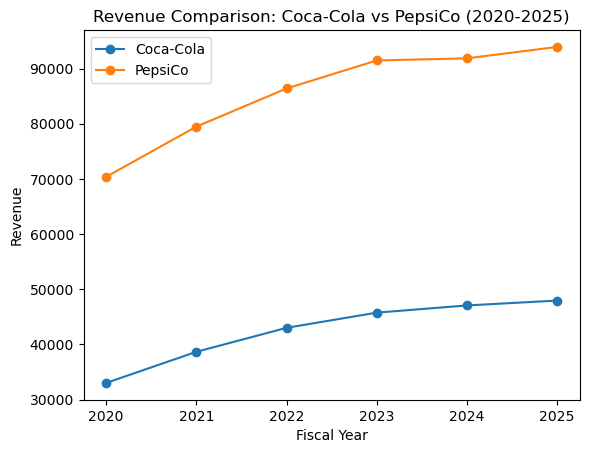

In [17]:
import matplotlib.pyplot as plt

for company in financial_data_clean["company"].unique():
    company_data = financial_data_clean[financial_data_clean["company"] == company]
    plt.plot(company_data["fyear"], company_data["sale"], marker="o", label=company)

plt.xlabel("Fiscal Year")
plt.ylabel("Revenue")
plt.title("Revenue Comparison: Coca-Cola vs PepsiCo (2020-2025)")
plt.legend()
plt.savefig("figures/revenue_comparison.png", bbox_inches="tight")
plt.show()

The chart shows that PepsiCo consistently generated higher revenue than Coca-Cola from 2020 to 2025.  
Both companies also experienced an overall upward trend in revenue during the sample period, suggesting business growth.

This indicates that PepsiCo operates at a larger business scale.  
However, higher revenue alone does not necessarily mean stronger overall financial performance, so further analysis is needed to evaluate profitability and financial stability.

### 7. Net Income Comparison


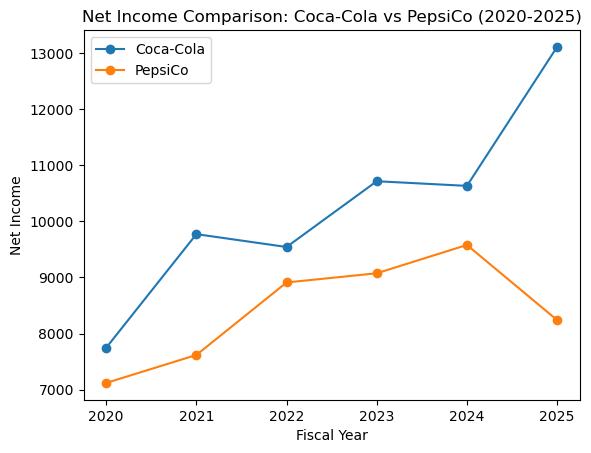

In [18]:
for company in financial_data_clean["company"].unique():
    company_data = financial_data_clean[financial_data_clean["company"] == company]
    plt.plot(company_data["fyear"], company_data["ni"], marker="o", label=company)

plt.xlabel("Fiscal Year")
plt.ylabel("Net Income")
plt.title("Net Income Comparison: Coca-Cola vs PepsiCo (2020-2025)")
plt.legend()
plt.savefig("figures/net_income_analysis.png", bbox_inches="tight")
plt.show()

Both Coca-Cola and PepsiCo reported solid net income during the period.  
Although PepsiCo generated much higher revenue, Coca-Cola maintained relatively strong net income performance.

This suggests that Coca-Cola may have been more efficient in converting sales into profit.  
Therefore, comparing net income together with revenue is important, because larger sales do not automatically lead to stronger profit performance.

### 8. Profitability Comparison

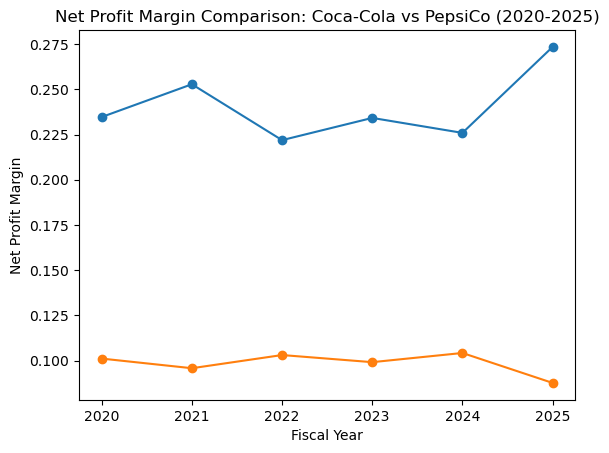

In [19]:
for company in financial_data_clean["company"].unique():
    company_data = financial_data_clean[financial_data_clean["company"] == company]
    plt.plot(company_data["fyear"], company_data["net_profit_margin"], marker="o", label=company)

plt.xlabel("Fiscal Year")
plt.ylabel("Net Profit Margin")
plt.title("Net Profit Margin Comparison: Coca-Cola vs PepsiCo (2020-2025)")
plt.legend
plt.savefig("figures/net_profit_margin_comparison.png", bbox_inches="tight")
plt.show()

Coca-Cola shows a consistently higher net profit margin than PepsiCo across most of the sample period.  
This indicates that Coca-Cola was more efficient in converting revenue into profit.

From a profitability perspective, Coca-Cola appears to perform better than PepsiCo.  
This result also highlights an important point in financial analysis: a company with lower revenue can still be more profitable if it manages its costs and operations more effectively.

### 9. Liquidity Comparison

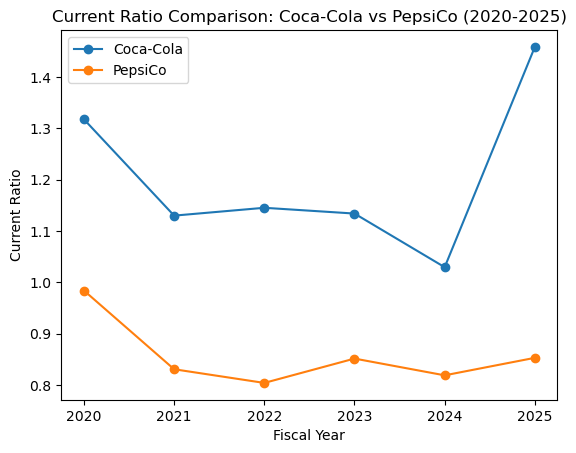

In [20]:
for company in financial_data_clean["company"].unique():
    company_data = financial_data_clean[financial_data_clean["company"] == company]
    plt.plot(company_data["fyear"], company_data["current_ratio"], marker="o", label=company)

plt.xlabel("Fiscal Year")
plt.ylabel("Current Ratio")
plt.title("Current Ratio Comparison: Coca-Cola vs PepsiCo (2020-2025)")
plt.legend()
plt.savefig("figures/liquidity_analysis.png", bbox_inches="tight")
plt.show()

Coca-Cola generally reports a higher current ratio than PepsiCo during the sample period.  
This suggests that Coca-Cola may have a stronger short-term liquidity position.

In other words, Coca-Cola appears to be better able to cover its current liabilities with its current assets.  
This is important because liquidity reflects short-term financial safety and helps evaluate whether a company can meet its immediate obligations.

### 10. Debt Ratio Comparison

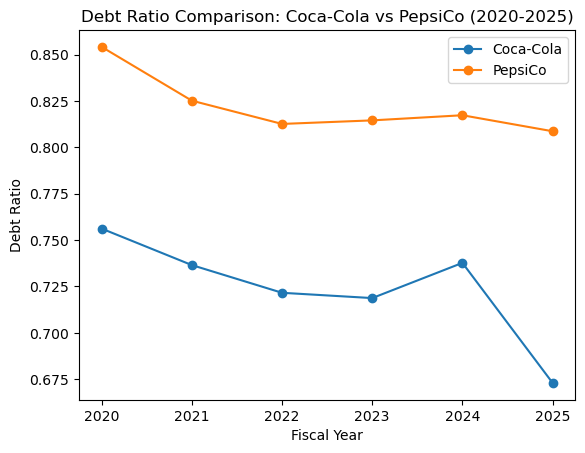

In [21]:
for company in financial_data_clean["company"].unique():
    company_data = financial_data_clean[financial_data_clean["company"] == company]
    plt.plot(company_data["fyear"], company_data["debt_ratio"], marker="o", label=company)

plt.xlabel("Fiscal Year")
plt.ylabel("Debt Ratio")
plt.title("Debt Ratio Comparison: Coca-Cola vs PepsiCo (2020-2025)")
plt.legend()
plt.savefig("figures/debt_ratio_comparison.png", bbox_inches="tight")
plt.show()

PepsiCo reports a higher debt ratio than Coca-Cola in most years.  
This suggests that PepsiCo relies more heavily on liabilities relative to total assets.

By comparison, Coca-Cola appears to have a more conservative capital structure and lower financial risk in this respect.  
This difference is important because a higher debt ratio may increase financial pressure, especially during periods of uncertainty or weaker business performance.

## 11. Overall Interpretation

The comparison between Coca-Cola and PepsiCo shows that the two companies have different financial strengths.  
PepsiCo generated consistently higher revenue from 2020 to 2025, which suggests that it operates at a larger business scale.  
However, Coca-Cola performed better in several ratio-based measures, including net profit margin, current ratio, and debt ratio.

This suggests that PepsiCo is stronger in size, while Coca-Cola appears to be stronger in profitability and short-term financial stability.  
In other words, PepsiCo sold more, but Coca-Cola seems to have converted its sales into profit more efficiently and maintained a more conservative financial structure.

Therefore, the answer depends on the analytical focus.  
If the focus is business scale, PepsiCo appears stronger.  
If the focus is profitability and financial stability, Coca-Cola appears to perform better.

## 12. Conclusion

This project compares the financial performance of Coca-Cola and PepsiCo from 2020 to 2025 using WRDS data.

The analysis shows that PepsiCo generated higher revenue throughout the sample period, indicating a larger business scale.  
However, Coca-Cola achieved a higher net profit margin, a generally higher current ratio, and a lower debt ratio in most years.

Overall, PepsiCo appears stronger in scale, while Coca-Cola appears stronger in profitability and financial stability.

## 13. Limitations

This project has several limitations.  
First, PepsiCo has a broader business structure than Coca-Cola, including major snack brands, so the two companies are not perfectly comparable.  
Second, the analysis focuses on a limited set of accounting variables and ratios, which cannot fully capture all aspects of company performance.  
Third, the study is descriptive and does not include forecasting or valuation analysis.